In [22]:
import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import *  #only needed for xgboost
import xgboost as xgb
from baselines import *

In [23]:
predictor_columns = ['zq5', 'zq10', 'zq15', 'zq20', 'zq25', 'zq30', 'zq35', 
                     'zq40', 'zq45', 'zq50', 'zq55', 'zq60', 'zq65', 'zq70',
                     'zq75', 'zq80', 'zq85', 'zq90', 'zq95',
                     'pzabove2', 'pzabovezmean', 'zmax']
target_column = 'Hgv'

In [24]:
data_source = pd.read_csv('datasets/rs_sweden.csv', index_col = [0])[0:1000]
data_target = pd.read_csv('datasets/rs_lettland.csv', index_col = [0])[0:200]
print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

data_temp, data_test = train_test_split(data_target, test_size=0.1, random_state=34)
data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=1)

print(f'train (target) dataset size: {len(data_train)}, val (target) dataset size: {len(data_val)}, test (target) dataset size: {len(data_test)}')


source dataset size: 1000, target dataset size: 200
train (target) dataset size: 162, val (target) dataset size: 18, test (target) dataset size: 20


In [25]:
data_target

,level_0,index,Plot,zmax,zmean,zsd,zskew,zkurt,zentropy,pzabovezmean,...,Y_mer,Korigets,Z_mer,DATE1,COMPANY,LIDAR_SCANNER,SCANNING YEAR,NFI_YEAR,DIFF,LIDAR_PATH
0,0,0,2434251134,21.14,3.899034,4.857550,1.223164,3.532031,NaN,35.441437,...,180624.644133,1.0,163.546713,20.05.2017.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, #SN 9997895, rot...",2017,2018,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
1,1,1,2434255331,22.75,11.171601,5.837539,-0.779335,2.566516,NaN,63.504634,...,NaN,NaN,NaN,21.05.2017.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, rotated polygon",2017,2016,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
2,2,2,2434443431,28.44,13.048838,8.114062,-0.568960,2.028040,NaN,64.169021,...,NaN,NaN,NaN,15.05.2017.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, #SN 9997895, rot...",2017,2016,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
3,3,3,2434443432,23.50,7.531918,6.659318,0.211702,1.492145,0.823146,47.906855,...,NaN,NaN,NaN,21.05.2017.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, rotated polygon",2017,2016,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
4,4,4,2434443433,29.58,8.547887,9.658435,0.607184,1.779415,NaN,42.686567,...,NaN,NaN,NaN,15.05.2017.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, #SN 9997895, rot...",2017,2016,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,206,206,3231345532,20.40,5.329607,5.994667,0.687252,1.954764,NaN,40.815237,...,NaN,NaN,NaN,21.04.2016.,ENVIROSENSE,ALS70-HP,2016,2015,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
196,207,207,3231345533,17.51,3.430613,5.251337,1.252634,2.975444,0.554555,30.373951,...,NaN,NaN,NaN,28.10.2014.,MGGP Aero Sp. z o.o.,"Riegl LMS Q680i, #SN 9998174, rotated polygon",2014,2015,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
197,208,208,3231523331,17.38,2.521898,4.565746,1.869140,5.086335,NaN,25.352113,...,NaN,NaN,NaN,21.04.2016.,ENVIROSENSE,ALS70-HP,2016,2017,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...
198,209,209,3231523332,18.28,0.478871,1.395673,4.528882,31.795735,NaN,11.571125,...,NaN,NaN,NaN,21.04.2016.,ENVIROSENSE,ALS70-HP,2016,2017,True,https://s3.storage.pub.lvdc.gov.lv/lgia-openda...


In [26]:
X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_val = np.array(data_val[predictor_columns])
y_target_val = np.array(data_val[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

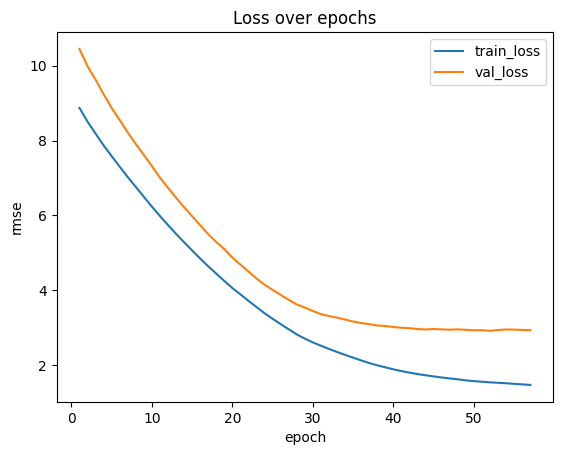

9.294481136624096


In [36]:
fiter = MTransferTreeBoost(epochs=300, source_tree_size=3, target_tree_size=3)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

print((rmse / np.mean(y_target_test))*100)

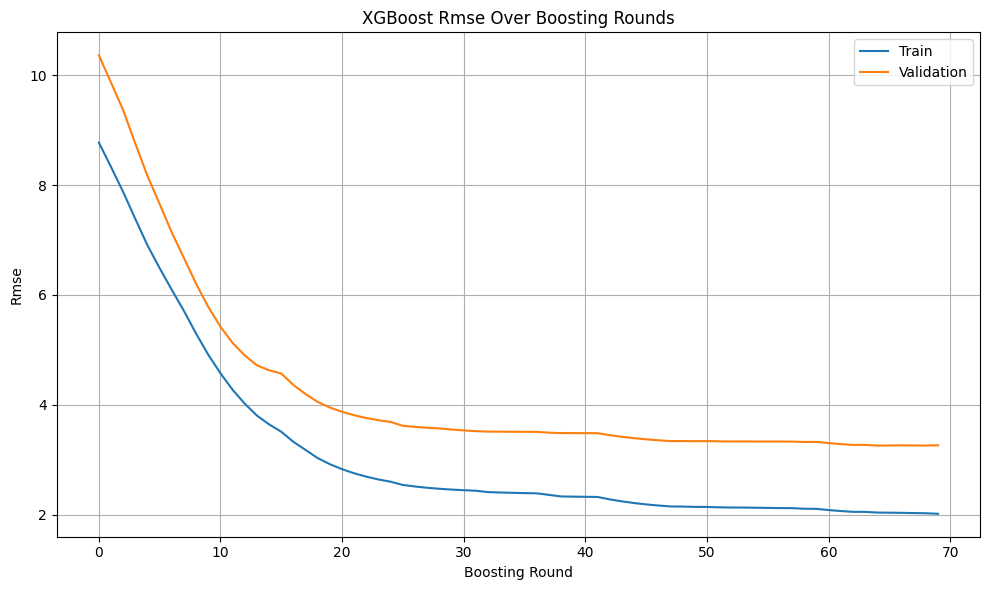

9.957114595744788


In [ ]:
params = {
    'objective': 'reg:absoluteerror',  # Regression with squared error
    'max_depth': 3,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test, bst)
val_preds = test_xgboost(X_target_val, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print((rmse / np.mean(y_target_test))*100)

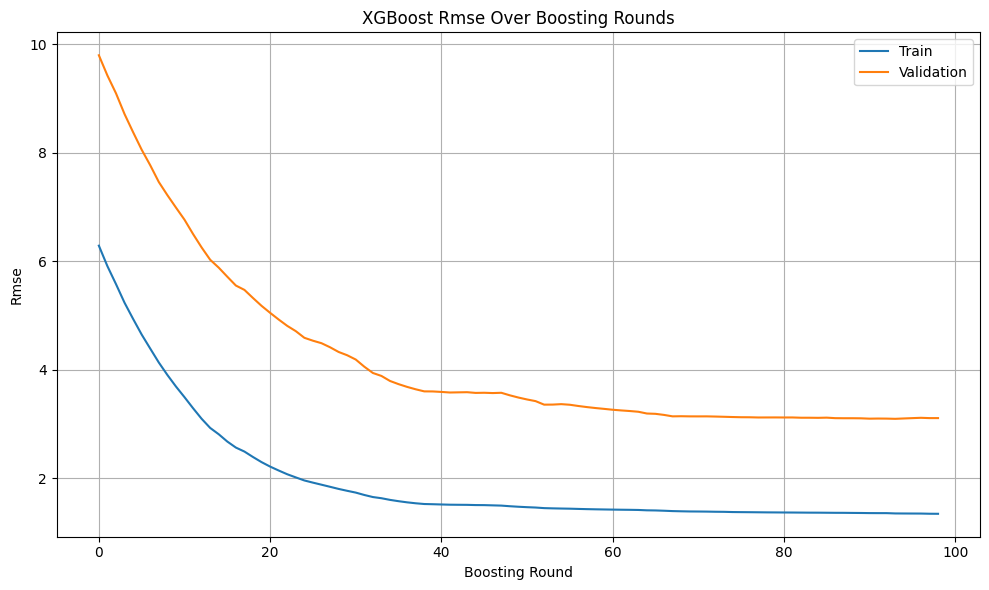

9.616263863397155


In [29]:
#additional source/target dummy sets for naive xgboost
ones = np.ones((len(X_target_train), 1))
X_target_train_with_dummy = np.hstack((X_target_train.copy(), ones))
ones = np.ones((len(X_target_val), 1))
X_target_val_with_dummy = np.hstack((X_target_val.copy(), ones))
ones = np.ones((len(X_target_test), 1))
X_target_test_with_dummy= np.hstack((X_target_test.copy(), ones))

zeros = np.zeros((len(X_source_train), 1))
X_source_train_with_dummy = np.hstack((X_source_train.copy(), zeros))

X_comb = np.concatenate((X_target_train_with_dummy, X_source_train_with_dummy)) 
y_comb = np.concatenate((y_target_train, y_source_train))       
bst = train_xgboost(X_comb, y_comb, X_target_val_with_dummy, y_target_val, boosting_rounds=100, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test_with_dummy, bst)
val_preds = test_xgboost(X_target_val_with_dummy, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

In [30]:
import warnings
warnings.filterwarnings('ignore')
from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.metrics import mean_squared_error, mean_absolute_error
from m5py import M5Prime

from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression

base_estimator = M5Prime()
model = TrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)
val_preds = model.predict(X_target_val)
val_rmse = np.sqrt(
    mean_squared_error(val_preds, y_target_val))
val_mae = mean_absolute_error(val_preds, y_target_val)
rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

Iteration 0 - Error: 0.1650
Iteration 1 - Error: 0.2475
Iteration 2 - Error: 0.4096
Iteration 3 - Error: 0.5280
Iteration 4 - Error: 0.6534
Iteration 5 - Error: 0.7853
Iteration 6 - Error: 0.8228
Iteration 7 - Error: 0.8480
Iteration 8 - Error: 0.8599
Iteration 9 - Error: 0.8874
Iteration 10 - Error: 0.8938
Iteration 11 - Error: 0.8992
Iteration 12 - Error: 0.9097
Iteration 13 - Error: 0.9178
Iteration 14 - Error: 0.9189
Iteration 15 - Error: 0.9293
Iteration 16 - Error: 0.9286
Iteration 17 - Error: 0.9394
Iteration 18 - Error: 0.9407
Iteration 19 - Error: 0.9263
Iteration 20 - Error: 0.9453
Iteration 21 - Error: 0.9482
Iteration 22 - Error: 0.9463
Iteration 23 - Error: 0.9578
Iteration 24 - Error: 0.9310
Iteration 25 - Error: 0.9579
Iteration 26 - Error: 0.9604
Iteration 27 - Error: 0.9624
Iteration 28 - Error: 0.9622
Iteration 29 - Error: 0.9648
8.71982897026396


In [31]:

# base_estimator = LinearTreeRegressor(
#     base_estimator=LinearRegression(),
#     max_depth=5,
#     min_samples_leaf=3)
base_estimator = M5Prime()
model = TwoStageTrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        n_estimators_fs=30,
                        cv=10,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)
val_preds = model.predict(X_target_val)
val_rmse = np.sqrt(
    mean_squared_error(val_preds, y_target_val))
val_mae = mean_absolute_error(val_preds, y_target_val)
rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

Iteration 0 - Cross-validation score: 2.3027 (0.7027)


KeyboardInterrupt: 

In [37]:
df = pd.DataFrame(columns = ['seed', 'method', 'rmse'])

for seed in range(89,91):
    data_source = pd.read_csv('datasets/rs_sweden.csv', index_col = [0])[0:1000]
    data_target = pd.read_csv('datasets/rs_lettland.csv', index_col = [0])[0:200]
    print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

    data_temp, data_test = train_test_split(data_target, test_size=0.1, random_state=seed)
    data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=seed)

    X_source_train = np.array(data_source[predictor_columns])
    y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

    #Specific train and test set
    X_target_train = np.array(data_train[predictor_columns])
    y_target_train = np.array(data_train[target_column])

    X_target_val = np.array(data_val[predictor_columns])
    y_target_val = np.array(data_val[target_column])

    X_target_test = np.array(data_test[predictor_columns])
    y_target_test = np.array(data_test[target_column])

    fiter = MTransferTreeBoost()
    fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = False)
    rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
    val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
    mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
    val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

    df.loc[len(df)] = [seed, 'MTransferTreeBoost', rmse]

    params = {
    'objective': 'reg:pseudohubererror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
    bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=False)
    preds = test_xgboost(X_target_test, bst)
    val_preds = test_xgboost(X_target_val, bst)
    val_rmse = compute_rmse(val_preds, y_target_val)
    val_mae = compute_mae(val_preds, y_target_val)
    rmse = compute_rmse(preds, y_target_test)
    mae = compute_mae(preds, y_target_test)

    df.loc[len(df)] = [seed, 'XGBoost', rmse]


    base_estimator = M5Prime()
    model = TrAdaBoostR2(base_estimator,
                            n_estimators=30,
                            lr=1, verbose = False)
    model.fit(X_source_train, y_source_train,
                X_target_train, y_target_train)
    preds = model.predict(X_target_test)
    val_preds = model.predict(X_target_val)
    val_rmse = np.sqrt(
        mean_squared_error(val_preds, y_target_val))
    val_mae = mean_absolute_error(val_preds, y_target_val)
    rmse = np.sqrt(mean_squared_error(
        preds, y_target_test))
    mae = mean_absolute_error(preds, y_target_test)

    df.loc[len(df)] = [seed, 'TrAdaBoost.R2', rmse]

source dataset size: 1000, target dataset size: 200
source dataset size: 1000, target dataset size: 200


<Axes: xlabel='method', ylabel='rmse'>

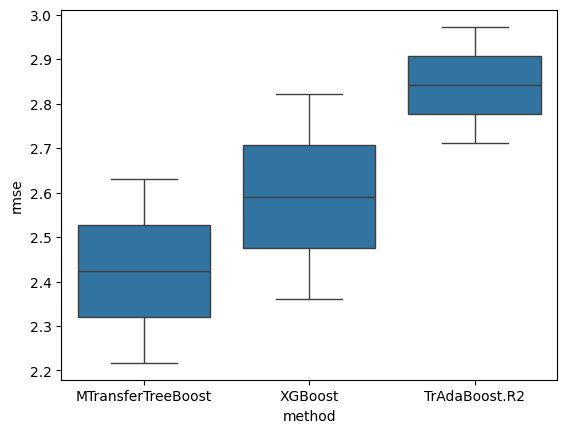

In [38]:
import seaborn as sns
sns.boxplot(data = df, x = 'method', y = 'rmse')
